In [8]:
import meta
import load
import analysis
import preprocess
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
np.random.seed(42)

In [12]:
records = []

# dataset = meta.datasets[0]
# records.extend(load.load_dataset(dataset))

dateset = meta.datasets[1]
records.extend(load.load_dataset(dateset))

  0%|          | 0/25 [00:00<?, ?it/s]

Error processing record 00735: sampto must be greater than sampfrom
Error processing record 03665: sampto must be greater than sampfrom


100%|██████████| 25/25 [00:18<00:00,  1.33it/s]

Loaded 23 records from afdb dataset.


In [13]:
auxnote_override_map = defaultdict(lambda: "Other")
auxnote_override_map['(AFIB'] = "AF"
auxnote_override_map['(AFL'] = "AF"

analysis.print_records_annotations(records)
records = preprocess.remove_auxnote_by_identifier(records, start_id='(V')  # remove (V events
analysis.print_records_annotations(records)
records = preprocess.override_auxnote(records, auxnote_override_map)
analysis.print_records_annotations(records)

Counter({'(AFIB': 291, '(N': 288, '(AFL': 14, '(J': 12})
Counter({'(AFIB': 291, '(N': 288, '(AFL': 14, '(J': 12})
Counter({'AF': 305, 'Other': 300})


## Preprocess Data

In [15]:
records = preprocess.preprocess_records(records, frequency_resample=True, bandpass_filter=True)
analysis.print_records_annotations(records)

100%|██████████| 23/23 [00:31<00:00,  1.39s/it]

Counter({'AF': 305, 'Other': 300})


## Generate Samples

In [16]:
# stratify resample records based on AF label
pct_test = 0.2
from sklearn.model_selection import train_test_split
record_with_af = np.array([record['df_ann']['AuxNote'].str.contains("AF").any() for record in records])
records_train, records_test = train_test_split(records, stratify=record_with_af, test_size=pct_test, random_state=42)
print(f"Train records size: {len(records_train)}")
print(f"Test records size: {len(records_test)}")

records_train_names = [record['record_name'] for record in records_train]
records_test_names = [record['record_name'] for record in records_test]
print(f"Train records names: {records_train_names}")
print(f"Test records names: {records_test_names}")

Train records size: 18
Test records size: 5
Train records names: ['05261', '08434', '07910', '06995', '08215', '04126', '08219', '07162', '05121', '04043', '04015', '04048', '04746', '06453', '07879', '04908', '08455', '08405']
Test records names: ['04936', '08378', '06426', '07859', '05091']


In [17]:
record_with_af

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [6]:
window_duration = 20  # seconds
stride_duration = 5  # seconds

auxnote_label_map = {"AF":1, "Other": 0}

freq_to_keeprate_map_train = {1:0.3, 2:1}
samples_train = preprocess.generate_samples_from_records(records_train, 
                                                    window_duration=window_duration, stride_duration=stride_duration, 
                                                    auxnote_label_map = auxnote_label_map, freq_to_keeprate_map = freq_to_keeprate_map_train)

freq_to_keeprate_map_test = {1:1, 2:1}
samples_test = preprocess.generate_samples_from_records(records_test,
                                                    window_duration=window_duration, stride_duration=window_duration, # non overlapping
                                                    auxnote_label_map = auxnote_label_map, freq_to_keeprate_map = freq_to_keeprate_map_test)

100%|██████████| 40689/40689 [01:53<00:00, 359.57it/s]


Generated 40689 samples from 18 records.


100%|██████████| 9205/9205 [00:25<00:00, 361.78it/s]

Generated 9205 samples from 5 records.


In [17]:
def select_samples_by_label(samples, output_pct, output_size):
    samples_selected = []
    for label, pct in output_pct.items():
        num_samples = int(output_size * pct)
        label_samples = [sample for sample in samples if sample['labels'] == label]
        print(f"Resampling {len(label_samples)} samples to {num_samples} samples for label {label}")
        if len(label_samples) > num_samples:
            label_samples = np.random.choice(label_samples, size=num_samples, replace=False)
        elif len(label_samples) < num_samples:
            label_samples = np.random.choice(label_samples, size=num_samples, replace=True)
        samples_selected.extend(label_samples)
    return samples_selected

def print_sample_labels(samples):
    counter = Counter([sample['labels'] for sample in samples])
    print(f"Sample labels: {counter}")


In [18]:
print_sample_labels(samples_train)
print_sample_labels(samples_test)

Sample labels: Counter({'0': 25546, '1': 13660, '01': 1483})
Sample labels: Counter({'1': 5503, '0': 3567, '01': 135})


In [20]:
#pct_by_label = {'0':0.33, '1':0.33, '01':0.33}
pct_by_label = {'0':0.5, '1':0.5, '01':0.0}
num_train_samples = 13468 * 2  #min(counter_train.values()) * 3
num_test_samples = 3567 * 2   #min(counter_test.values()) * 3
samples_train_selected = select_samples_by_label(samples_train, pct_by_label, num_train_samples)
samples_test_selected = select_samples_by_label(samples_test, pct_by_label, num_test_samples)

# print the resampled label counters
# counter_train_selected = Counter([sample['labels'] for sample in samples_train_selected])
# counter_test_selected = Counter([sample['labels'] for sample in samples_test_selected])
# print(f"Selected train labels: {counter_train_selected}")
# print(f"Selected test labels: {counter_test_selected}")
print_sample_labels(samples_train_selected)
print_sample_labels(samples_test_selected)

Resampling 25546 samples to 13468 samples for label 0
Resampling 13660 samples to 13468 samples for label 1
Resampling 1483 samples to 0 samples for label 01
Resampling 3567 samples to 3567 samples for label 0
Resampling 5503 samples to 3567 samples for label 1
Resampling 135 samples to 0 samples for label 01
Sample labels: Counter({'0': 13468, '1': 13468})
Sample labels: Counter({'0': 3567, '1': 3567})


In [ ]:
# num_classes = len(auxnote_label_map)
# X_train, Y_train_class = preprocess.generate_inputs_from_samples(samples_train_selected)
# X_test, Y_test_class = preprocess.generate_inputs_from_samples(samples_test_selected)
# Y_train = preprocess.class_to_onehot(Y_train_class, num_classes=num_classes)
# Y_test = preprocess.class_to_onehot(Y_test_class, num_classes=num_classes)
# print(f"Train set shape: {X_train.shape}, {Y_train.shape}")
# print(f"Test set shape: {X_test.shape}, {Y_test.shape}")

X_train, Y_train = preprocess.generate_inputs_from_samples(samples_train_selected)
X_test, Y_test = preprocess.generate_inputs_from_samples(samples_test_selected)
print(f"Train set shape: {X_train.shape}, {Y_train.shape}")
print(f"Test set shape: {X_test.shape}, {Y_test.shape}")

100%|██████████| 26936/26936 [00:04<00:00, 6618.10it/s]


Generated 26936 samples
X shape: (26936, 4000) y shape: (26936, 20)


100%|██████████| 7134/7134 [00:01<00:00, 6126.30it/s]

Generated 7134 samples
X shape: (7134, 4000) y shape: (7134, 20)
Train set shape: (26936, 4000), (26936, 20)
Test set shape: (7134, 4000), (7134, 20)


In [36]:
Y_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=int64)

## Prepare for Training

In [38]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             filter_sizes = {1:16, 2:32, 3:64}, kernel_sizes = {1:7, 2:5, 3:3}, dropout_rates={1:0.2, 2:0.2, 3:0.2},
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):
    
    output_size = unit_size
    print(f"Class weights: {class_weights}")
    ####################################################################
    # output_size = unit_size * class_size  # output size is the number of classes times the number of units
    # print("Class Weights:", class_weights)
    
    # def custom_loss(y_true, y_pred):
    #     if class_size != len(class_weights):
    #         raise ValueError("The length of class_weights must match the number of classes.")
        
    #     # Reshape tensors
    #     y_true = tf.reshape(y_true, [-1, unit_size, class_size])
    #     y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

    #     loss = 0.0
    #     if loss_type == 'cross_entropy':
    #         for i in range(class_size):
    #             if class_weights[i] > 0:
    #                 loss += class_weights[i] * tf.reduce_mean(
    #                     -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
    #                 )
    #     elif loss_type == 'mse':
    #         for i in range(class_size):
    #             if class_weights[i] > 0:
    #                 loss += class_weights[i] * tf.reduce_mean(
    #                     tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
    #                 )
    #     else:
    #         raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
    #     return loss

    # def custom_accuracy(y_true, y_pred):
    #     y_true = tf.reshape(y_true, [-1, unit_size, class_size])
    #     y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
    #     correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
    #     return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(filter_sizes[1], kernel_size=kernel_sizes[1], padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[1])(x)

    # Block 2
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[2])(x)
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)

    # Block 3
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[3])(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)

    # Final block
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    #model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)

In [44]:
model, history=network(X_train, Y_train, X_test, Y_test,
                       filter_sizes={1: 8, 2: 16, 3: 32},
                       kernel_sizes={1: 3, 2: 3, 3: 3}, 
                       dropout_rates={1: 0.3, 2: 0.3, 3: 0.3},
                       unit_size=window_duration, 
                       class_size=None,
                       class_weights={0: 0.5, 1: 0.5},
                       learning_rate=0.0001, batch_size=32, epochs=10, loss_type='cross_entropy', modelCheckPoint=False)

Class weights: {0: 0.5, 1: 0.5}
Epoch 1/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 89s 104ms/step - accuracy: 0.0373 - loss: 0.6958 - val_accuracy: 0.9592 - val_loss: 0.7010
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 87s 104ms/step - accuracy: 0.5767 - loss: 0.6776 - val_accuracy: 0.9654 - val_loss: 0.7245
Epoch 3/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 88s 105ms/step - accuracy: 0.2533 - loss: 0.6541 - val_accuracy: 0.9015 - val_loss: 0.7571
Epoch 4/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 90s 107ms/step - accuracy: 0.2717 - loss: 0.6268 - val_accuracy: 0.8664 - val_loss: 0.8178
Epoch 5/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 89s 105ms/step - accuracy: 0.2777 - loss: 0.6081 - val_accuracy: 0.8810 - val_loss: 0.8430
Epoch 6/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 90s 106ms/step - accuracy: 0.2713 - loss: 0.5841 - val_accuracy: 0.8531 - val_loss: 0.8761
Epoch 7/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 90s 107ms/step - accuracy: 0.2494 - loss: 0.5658 - val_accuracy: 0.6978 - val_loss: 0.8630
Epoch 8/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 89s 105ms/s

In [45]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 4000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 4000, 8)        │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 4000, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 4000, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4000, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 4000, 16)       │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 4000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 4000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 4000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 4000, 16)       │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 4000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 4000, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 4000, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 4000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 4000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 4000, 32)       │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 4000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 4000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,478 (80.00 KB)

 Trainable params: 6,756 (26.39 KB)

 Non-trainable params: 208 (832.00 B)

 Optimizer params: 13,514 (52.79 KB)

### Error Analysis

Accuracy: 33.33%


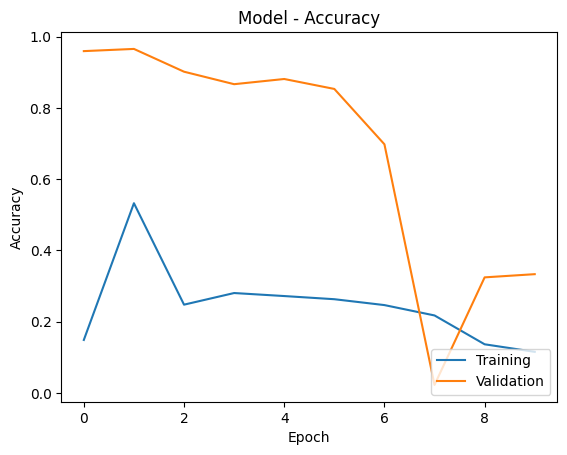

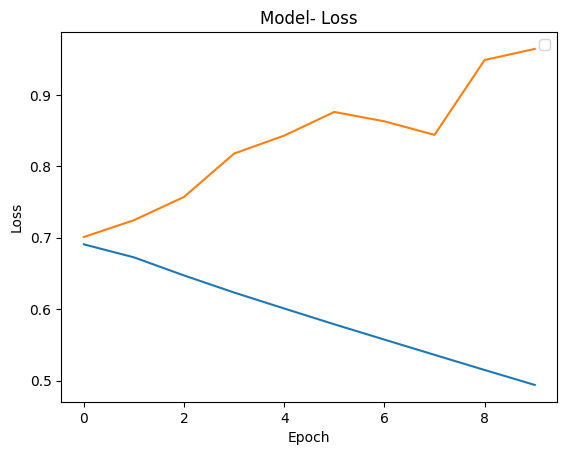

In [47]:
analysis.plot_accuracy_and_loss(history, X_test, Y_test, model, accuracy_keys = ['accuracy', 'val_accuracy'])

In [102]:
X_test.shape, Y_test.shape

((399, 4000), (399, 40))

In [137]:
Y_pred_onehot = model.predict(X_test)
Y_pred_class = preprocess.onehot_to_class(Y_pred_onehot, num_classes=num_classes)
Y_test_onehot = Y_test.copy()
Y_test_class = preprocess.onehot_to_class(Y_test_onehot, num_classes=num_classes)

# calculate the accuracy for each class
for i in range(num_classes):
    acc = np.sum((Y_test_class == i) & (Y_pred_class == i)) / np.sum(Y_test_class == i)
    print(f"Accuracy for class {i}: {acc:.2f}")

223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy for class 0: 0.82
Accuracy for class 1: 0.30


In [138]:
# calculate the confusion matrix based on Y_test_class and Y_pred_class
C = np.zeros((num_classes, num_classes))
for i in range(len(Y_test_class)):
    for j in range(len(Y_test_class[i])):
        C[int(Y_test_class[i][j]), int(Y_pred_class[i][j])] += 1
print("Confusion Matrix:")
print(C)

Confusion Matrix:
[[58581. 12759.]
 [49877. 21463.]]


In [ ]:
y_pred=model.predict(X_test)
cnf_matrix = confusion_matrix(Y_test, y_pred.argmax(axis=1))
plot_confusion_matrix(cnf_matrix, classes=['N', 'AFib', 'AFlu'], normalize=True)

In [ ]:
# from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# import tensorflow as tf

# def network(X_train, y_train, X_test, y_test,
#              unit_size, class_size, class_weights,
#              learning_rate=0.001, batch_size = 32, epochs=40, 
#              loss_type='cross_entropy', modelCheckPoint=False):    
#     ####################################################################
#     output_size = unit_size * class_size  # output size is the number of classes times the number of units
#     print("Class Weights:", class_weights)
    
#     def custom_loss(y_true, y_pred):
#         if class_size != len(class_weights):
#             raise ValueError("The length of class_weights must match the number of classes.")
        
#         # Reshape tensors
#         y_true = tf.reshape(y_true, [-1, unit_size, class_size])
#         y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

#         loss = 0.0
#         if loss_type == 'cross_entropy':
#             for i in range(len(class_weights)):
#                 if class_weights[i] > 0:
#                     loss += class_weights[i] * tf.reduce_mean(
#                         -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
#                     )
#         elif loss_type == 'mse':
#             for i in range(len(class_weights)):
#                 if class_weights[i] > 0:
#                     loss += class_weights[i] * tf.reduce_mean(
#                         tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
#                     )
#         else:
#             raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
#         return loss

#     def custom_accuracy(y_true, y_pred):
#         y_true = tf.reshape(y_true, [-1, unit_size, class_size])
#         y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
#         correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
#         return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

#     ####################################################################
#     inputs_cnn = Input(shape=(X_train.shape[1], 1))

#     # Block 1
#     x = Conv1D(16, kernel_size=7, padding='same')(inputs_cnn)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)

#     # Block 2
#     x = Conv1D(32, kernel_size=5, padding='same')(x)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = Dropout(0.2)(x)
#     x = Conv1D(32, kernel_size=3, padding='same')(x)

#     # Block 3
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = Conv1D(64, kernel_size=3, padding='same')(x)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = Dropout(0.2)(x)
#     x = Conv1D(64, kernel_size=3, padding='same')(x)

#     # Final block
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = GlobalAveragePooling1D()(x)

#     # Output layer
#     outputs_cnn = Dense(output_size, activation='softmax')(x)

#     optimizer = Adam(learning_rate=learning_rate)
#     model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
#     model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])

#     # define callbacks for early stopping and saving the best model with lowest validation loss
#     callbacks = [EarlyStopping(monitor='val_loss', patience=8)]
#     if modelCheckPoint:
#         callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
#     history=model.fit(X_train, y_train, epochs=epochs, 
#                       callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
#                       #class_weight=class_weights # assign class weights to the model 
#                       ) 
#     if modelCheckPoint:
#         model.load_weights('best_model.h5')
#     return (model, history)

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             filter_sizes = {1:16, 2:32, 3:64}, kernel_sizes = {1:7, 2:5, 3:3}, dropout_rates={1:0.2, 2:0.2, 3:0.2},
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):
    ####################################################################
    output_size = unit_size * class_size  # output size is the number of classes times the number of units
    print("Class Weights:", class_weights)
    
    def custom_loss(y_true, y_pred):
        if class_size != len(class_weights):
            raise ValueError("The length of class_weights must match the number of classes.")
        
        # Reshape tensors
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

        loss = 0.0
        if loss_type == 'cross_entropy':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
                    )
        elif loss_type == 'mse':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
                    )
        else:
            raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
        return loss

    def custom_accuracy(y_true, y_pred):
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
        correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
        return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(filter_sizes[1], kernel_size=kernel_sizes[1], padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[1])(x)

    # Block 2
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[2])(x)
    #x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)

    # Block 3
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[3])(x)
    #x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)

    # Final block
    # x = BatchNormalization()(x)
    # x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)


In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             filter_sizes = {1:16, 2:32, 3:64}, kernel_sizes = {1:7, 2:5, 3:3}, dropout_rates={1:0.2, 2:0.2, 3:0.2},
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):
    ####################################################################
    output_size = unit_size * class_size  # output size is the number of classes times the number of units
    print("Class Weights:", class_weights)
    
    def custom_loss(y_true, y_pred):
        if class_size != len(class_weights):
            raise ValueError("The length of class_weights must match the number of classes.")
        
        # Reshape tensors
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

        loss = 0.0
        if loss_type == 'cross_entropy':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
                    )
        elif loss_type == 'mse':
            for i in range(class_size):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
                    )
        else:
            raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
        return loss

    def custom_accuracy(y_true, y_pred):
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
        correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
        return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(filter_sizes[1], kernel_size=kernel_sizes[1], padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[1])(x)

    # Block 2
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[2])(x)
    x = Conv1D(filter_sizes[2], kernel_size=kernel_sizes[2], padding='same')(x)

    # Block 3
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(dropout_rates[3])(x)
    x = Conv1D(filter_sizes[3], kernel_size=kernel_sizes[3], padding='same')(x)

    # Final block
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)